In [2]:
import os
import gc
import time
import random
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [6]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

initial_train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

initial_validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

development_df = pd.concat(
    [initial_train_df, initial_validation_df],
    ignore_index=True
)

development_df = development_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Development images:", len(development_df))
print(development_df["label"].value_counts().sort_index())

print("\nUntouched test images:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Development images: 37400
label
0    10880
1    26520
Name: count, dtype: int64

Untouched test images: 6600
label
0    1920
1    4680
Name: count, dtype: int64


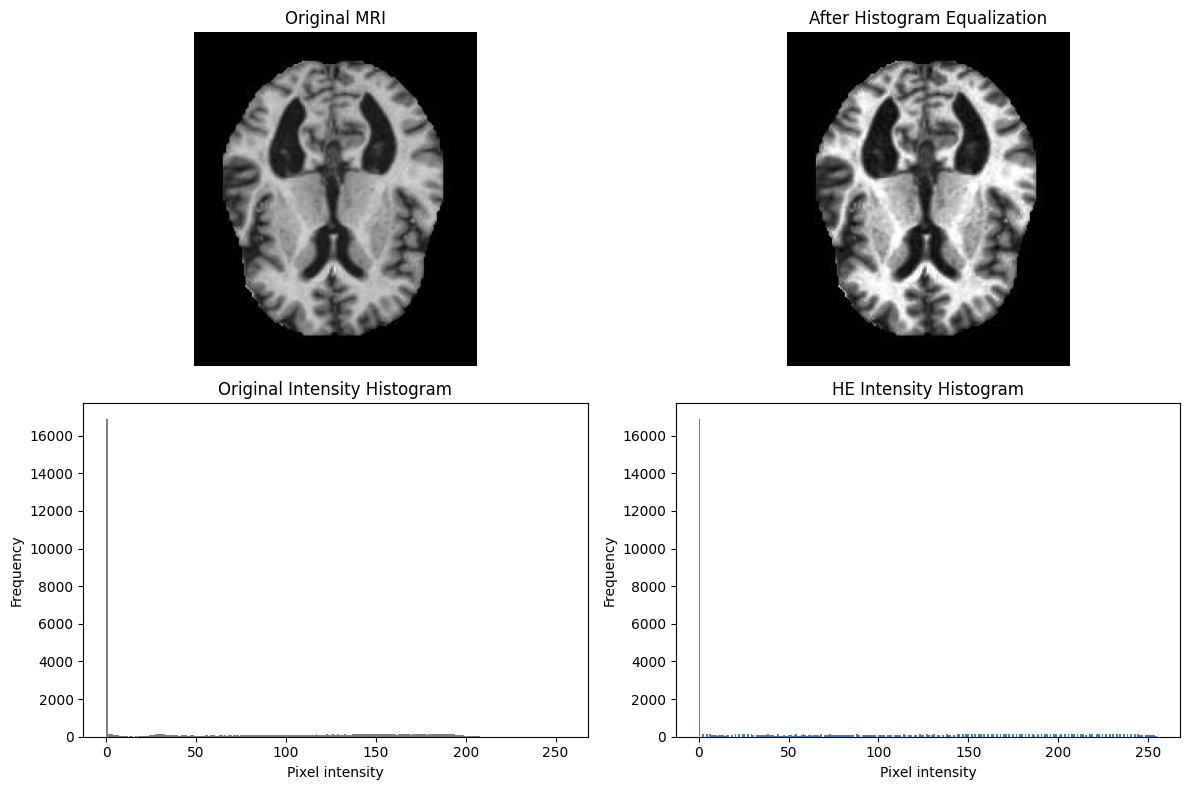

Original pixel range: 0 to 255
HE pixel range: 0 to 255


In [8]:
sample_path = development_df.sample(
    1,
    random_state=SEED
)["filepath"].iloc[0]

original_image = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

he_image = cv2.equalizeHist(original_image)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(he_image, cmap="gray")
plt.title("After Histogram Equalization")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.hist(original_image.ravel(), bins=256, color="gray")
plt.title("Original Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.hist(he_image.ravel(), bins=256, color="steelblue")
plt.title("HE Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Original pixel range:", original_image.min(), "to", original_image.max())
print("HE pixel range:", he_image.min(), "to", he_image.max())

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def apply_he(image):
    image = image.numpy()
    return cv2.equalizeHist(image)


def load_he_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=1,
        expand_animations=False
    )
    image.set_shape([None, None, 1])

    image = tf.squeeze(image, axis=-1)

    image = tf.py_function(
        apply_he,
        [image],
        Tout=tf.uint8
    )
    image.set_shape([None, None])

    image = tf.image.resize(
        image[..., tf.newaxis],
        IMG_SIZE
    )

    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_he_dataset(
    dataframe,
    training=False,
    shuffle_seed=SEED
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=shuffle_seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_he_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


test_dataset = create_he_dataset(test_df)

for images, labels in test_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())

I0000 00:00:1787807759.262497      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


In [10]:
from sklearn.model_selection import StratifiedKFold

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001
N_FOLDS = 5

cross_validator = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

for fold, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    fold_train_df = development_df.iloc[train_indices]
    fold_validation_df = development_df.iloc[validation_indices]

    print(
        f"Fold {fold}: "
        f"Training = {len(fold_train_df)}, "
        f"Validation = {len(fold_validation_df)}"
    )

print("\nMaximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Preprocessing: HE")
print("Augmentation: Disabled")

Fold 1: Training = 29920, Validation = 7480
Fold 2: Training = 29920, Validation = 7480
Fold 3: Training = 29920, Validation = 7480
Fold 4: Training = 29920, Validation = 7480
Fold 5: Training = 29920, Validation = 7480

Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Preprocessing: HE
Augmentation: Disabled


In [11]:
def build_resnet50(fold_seed):
    tf.keras.utils.set_random_seed(fold_seed)

    resnet_base = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    resnet_base.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = resnet_base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="ResNet50_HE_NoAug_CV"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


sample_model = build_resnet50(SEED)

print("Total parameters:", sample_model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in sample_model.trainable_weights
    )
)
print(
    "ResNet50 frozen:",
    not sample_model.get_layer("resnet50").trainable
)

del sample_model
tf.keras.backend.clear_session()
gc.collect()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True


0

In [12]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

fold_histories = {}
fold_results = []
fold_test_probabilities = []
fold_model_paths = []

print("HE cross-validation storage initialized.")

HE cross-validation storage initialized.


In [13]:
for fold, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    print(
        f"\n{'=' * 20} "
        f"FOLD {fold}/{N_FOLDS} "
        f"{'=' * 20}"
    )

    fold_train_df = development_df.iloc[
        train_indices
    ].reset_index(drop=True)

    fold_validation_df = development_df.iloc[
        validation_indices
    ].reset_index(drop=True)

    train_dataset = create_he_dataset(
        fold_train_df,
        training=True,
        shuffle_seed=SEED + fold
    )

    validation_dataset = create_he_dataset(
        fold_validation_df
    )

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=fold_train_df["label"]
    )

    fold_class_weights = {
        0: float(weights[0]),
        1: float(weights[1])
    }

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_resnet50(SEED + fold)

    model_path = (
        f"/kaggle/working/"
        f"resnet50_he_noaug_cv_fold_{fold}.keras"
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=MAX_EPOCHS,
        class_weight=fold_class_weights,
        callbacks=callbacks,
        verbose=1
    )

    training_minutes = (
        time.time() - start_time
    ) / 60

    history_df = pd.DataFrame(history.history)
    best_index = history_df["val_loss"].idxmin()

    fold_histories[fold] = history_df
    fold_model_paths.append(model_path)

    validation_probabilities = model.predict(
        validation_dataset,
        verbose=0
    ).ravel()

    validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(int)

    validation_labels = fold_validation_df[
        "label"
    ].to_numpy()

    fold_results.append({
        "Fold": fold,
        "Epochs Trained": len(history_df),
        "Best Epoch": best_index + 1,
        "Training Loss": history_df.loc[
            best_index, "loss"
        ],
        "Training Accuracy": history_df.loc[
            best_index, "accuracy"
        ],
        "Validation Loss": history_df.loc[
            best_index, "val_loss"
        ],
        "Validation Accuracy": accuracy_score(
            validation_labels,
            validation_predictions
        ),
        "Precision": precision_score(
            validation_labels,
            validation_predictions
        ),
        "Recall": recall_score(
            validation_labels,
            validation_predictions
        ),
        "F1-score": f1_score(
            validation_labels,
            validation_predictions
        ),
        "ROC-AUC": roc_auc_score(
            validation_labels,
            validation_probabilities
        ),
        "Training Minutes": training_minutes
    })

    fold_test_probabilities.append(
        model.predict(
            test_dataset,
            verbose=0
        ).ravel()
    )

    print(
        f"Fold {fold} completed in "
        f"{training_minutes:.2f} minutes"
    )

    del model, train_dataset, validation_dataset
    tf.keras.backend.clear_session()
    gc.collect()


==================== FOLD 1/5 ====================
Epoch 1/30
  3/935 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.4601 - loss: 0.9960   

I0000 00:00:1787807787.474107     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5441 - loss: 0.7669
Epoch 1: val_loss improved from None to 0.55930, saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 152s 149ms/step - accuracy: 0.5971 - loss: 0.7015 - val_accuracy: 0.7167 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 2/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6602 - loss: 0.6174
Epoch 2: val_loss did not improve from 0.55930
935/935 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.6743 - loss: 0.6034 - val_accuracy: 0.7151 - val_loss: 0.5597 - learning_rate: 1.0000e-04
Epoch 3/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6970 - loss: 0.5738
Epoch 3: val_loss improved from 0.55930 to 0.51446, saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras

Epoch 3: finished saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras
935

In [14]:
fold_results_df = pd.DataFrame(fold_results)

display(
    fold_results_df.round(4)
)

print(
    "\nMean validation accuracy:",
    round(
        fold_results_df[
            "Validation Accuracy"
        ].mean(),
        4
    )
)

print(
    "Validation accuracy standard deviation:",
    round(
        fold_results_df[
            "Validation Accuracy"
        ].std(),
        4
    )
)

print(
    "Mean validation ROC-AUC:",
    round(
        fold_results_df[
            "ROC-AUC"
        ].mean(),
        4
    )
)

,Fold,Epochs Trained,Best Epoch,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Minutes
0,1,13,8,0.4998,0.7501,0.4497,0.7921,0.8695,0.8316,0.8501,0.8509,18.4861
1,2,13,8,0.4990,0.7510,0.4569,0.7937,0.8812,0.8196,0.8493,0.8552,17.7997
2,3,8,3,0.5647,0.7101,0.4815,0.7765,0.8664,0.8096,0.8370,0.8346,11.0717
3,4,17,12,0.4859,0.7628,0.4561,0.7798,0.8860,0.7913,0.8360,0.8604,23.4220
4,5,28,23,0.4722,0.7707,0.4368,0.7952,0.8946,0.8062,0.8481,0.8758,37.5718



Mean validation accuracy: 0.7875
Validation accuracy standard deviation: 0.0087
Mean validation ROC-AUC: 0.8554


In [15]:
summary_columns = [
    "Training Loss",
    "Training Accuracy",
    "Validation Loss",
    "Validation Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "Training Minutes"
]

cv_summary = pd.DataFrame({
    "Mean": fold_results_df[
        summary_columns
    ].mean(),

    "Standard Deviation": fold_results_df[
        summary_columns
    ].std()
})

display(cv_summary.round(4))

,Mean,Standard Deviation
Training Loss,0.5043,0.0356
Training Accuracy,0.7489,0.0233
Validation Loss,0.4562,0.0163
Validation Accuracy,0.7875,0.0087
Precision,0.8795,0.0117
Recall,0.8117,0.0151
F1-score,0.8441,0.0070
ROC-AUC,0.8554,0.0150
Training Minutes,21.6703,9.9169


In [16]:
test_probabilities_cv = np.mean(
    np.vstack(fold_test_probabilities),
    axis=0
)

test_predictions_cv = (
    test_probabilities_cv >= 0.5
).astype(int)

true_test_labels = test_df[
    "label"
].to_numpy()

print("Test images:", len(true_test_labels))
print("Fold prediction arrays:", len(fold_test_probabilities))
print("Ensemble probabilities:", len(test_probabilities_cv))
print("Ensemble predictions:", len(test_predictions_cv))

print(
    "First ensemble probabilities:",
    test_probabilities_cv[:10].round(4)
)

Test images: 6600
Fold prediction arrays: 5
Ensemble probabilities: 6600
Ensemble predictions: 6600
First ensemble probabilities: [0.8092 0.5637 0.8826 0.6543 0.7856 0.8048 0.6579 0.5161 0.9989 0.9415]


In [17]:
from sklearn.metrics import log_loss

test_loss_cv = log_loss(
    true_test_labels,
    test_probabilities_cv
)

test_accuracy_cv = accuracy_score(
    true_test_labels,
    test_predictions_cv
)

print("Test Loss:", round(test_loss_cv, 4))
print("Test Accuracy:", round(test_accuracy_cv, 4))

Test Loss: 0.4624
Test Accuracy: 0.7802


In [18]:
from sklearn.metrics import classification_report

test_precision_cv = precision_score(
    true_test_labels,
    test_predictions_cv
)

test_recall_cv = recall_score(
    true_test_labels,
    test_predictions_cv
)

test_f1_cv = f1_score(
    true_test_labels,
    test_predictions_cv
)

test_roc_auc_cv = roc_auc_score(
    true_test_labels,
    test_probabilities_cv
)

print("Test Loss:", round(test_loss_cv, 4))
print("Accuracy:", round(test_accuracy_cv, 4))
print("Precision:", round(test_precision_cv, 4))
print("Recall:", round(test_recall_cv, 4))
print("F1-score:", round(test_f1_cv, 4))
print("ROC-AUC:", round(test_roc_auc_cv, 4))

print("\nClassification Report:\n")
print(
    classification_report(
        true_test_labels,
        test_predictions_cv,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

Test Loss: 0.4624
Accuracy: 0.7802
Precision: 0.877
Recall: 0.8026
F1-score: 0.8381
ROC-AUC: 0.8514

Classification Report:

              precision    recall  f1-score   support

 NonDemented     0.6012    0.7255    0.6575      1920
    Demented     0.8770    0.8026    0.8381      4680

    accuracy                         0.7802      6600
   macro avg     0.7391    0.7640    0.7478      6600
weighted avg     0.7967    0.7802    0.7856      6600



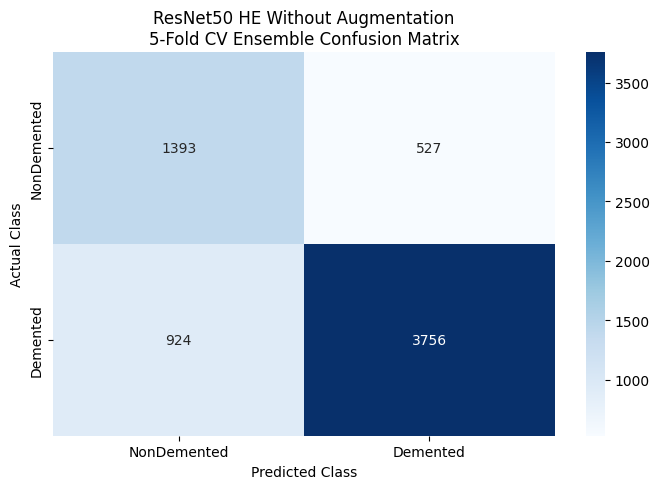

In [19]:
from sklearn.metrics import confusion_matrix

confusion_cv = confusion_matrix(
    true_test_labels,
    test_predictions_cv
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_cv,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title(
    "ResNet50 HE Without Augmentation\n"
    "5-Fold CV Ensemble Confusion Matrix"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

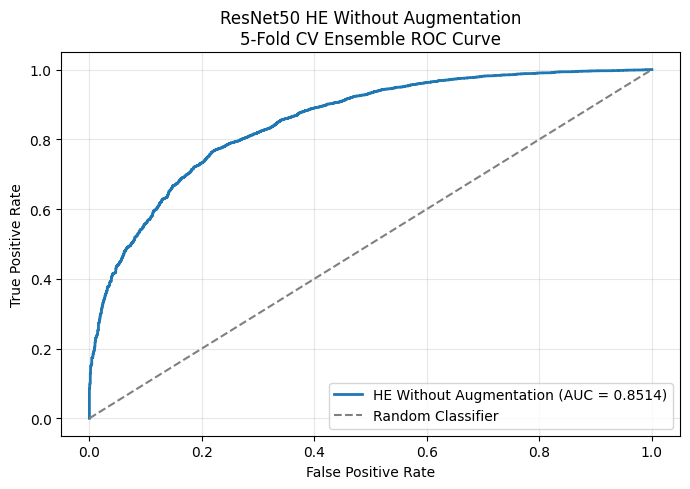

In [20]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    true_test_labels,
    test_probabilities_cv
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=(
        "HE Without Augmentation "
        f"(AUC = {test_roc_auc_cv:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title(
    "ResNet50 HE Without Augmentation\n"
    "5-Fold CV Ensemble ROC Curve"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

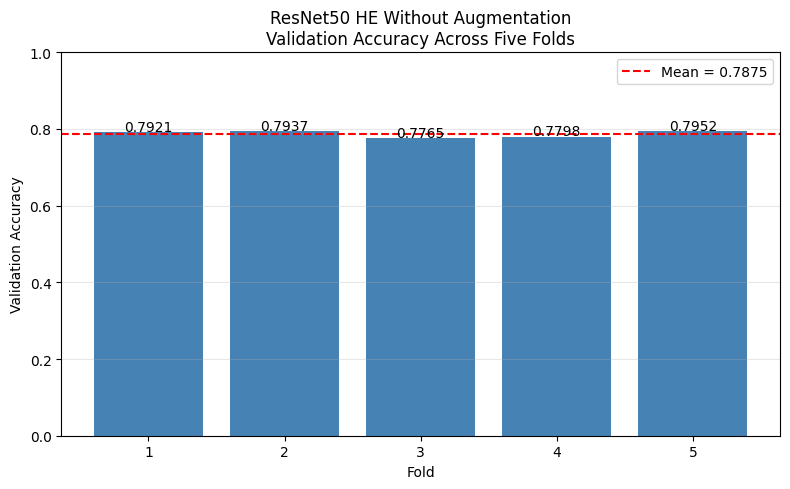

In [21]:
mean_validation_accuracy = fold_results_df[
    "Validation Accuracy"
].mean()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    fold_results_df["Fold"],
    fold_results_df["Validation Accuracy"],
    color="steelblue"
)

plt.axhline(
    mean_validation_accuracy,
    color="red",
    linestyle="--",
    label=f"Mean = {mean_validation_accuracy:.4f}"
)

for bar, value in zip(
    bars,
    fold_results_df["Validation Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.003,
        f"{value:.4f}",
        ha="center"
    )

plt.ylim(0, 1)
plt.title(
    "ResNet50 HE Without Augmentation\n"
    "Validation Accuracy Across Five Folds"
)
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.xticks(fold_results_df["Fold"])
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

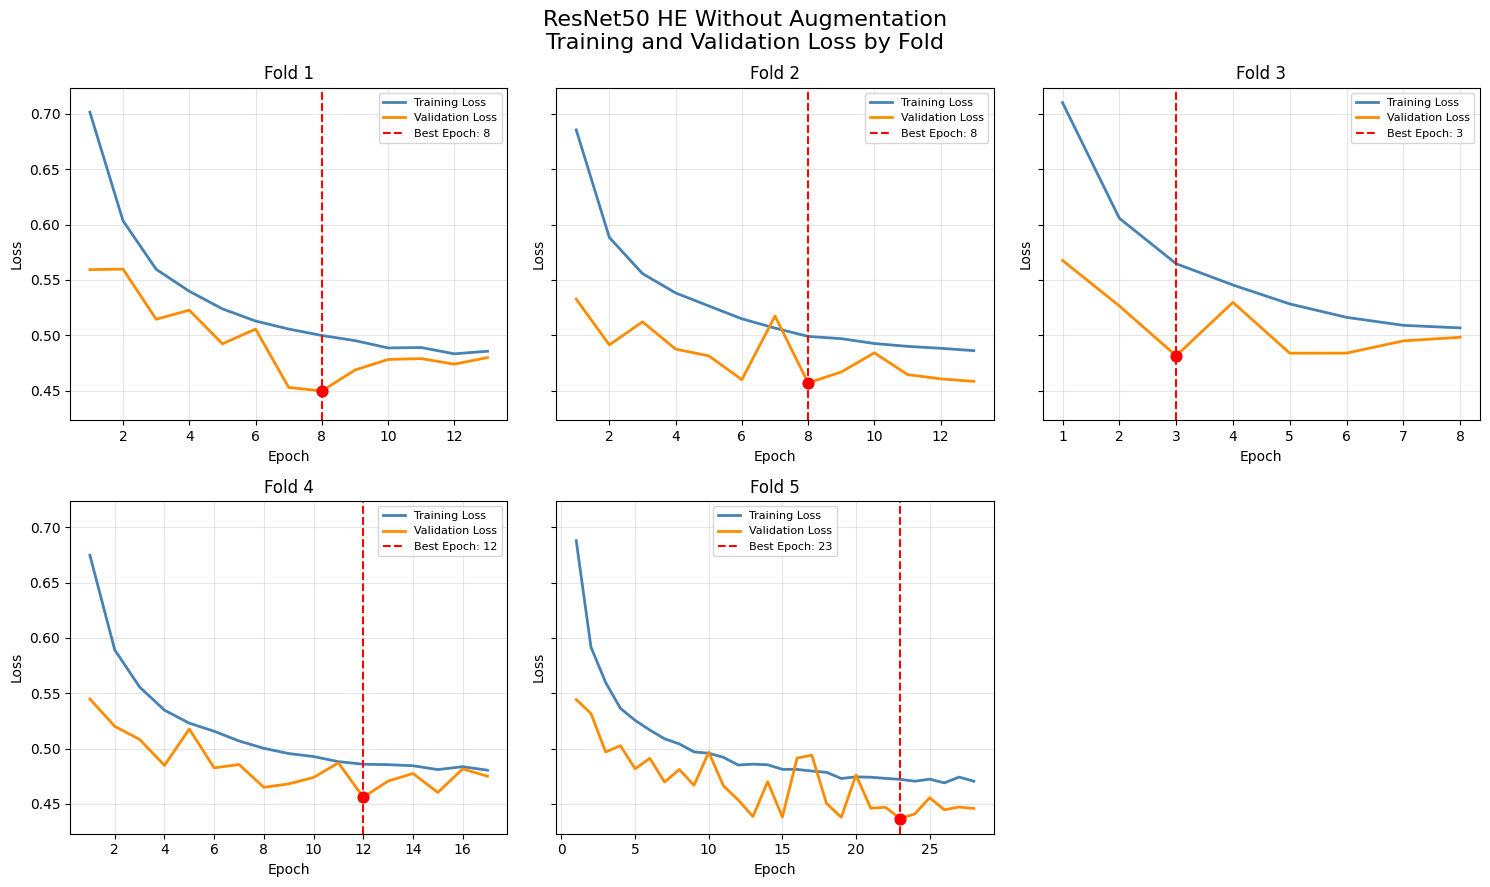

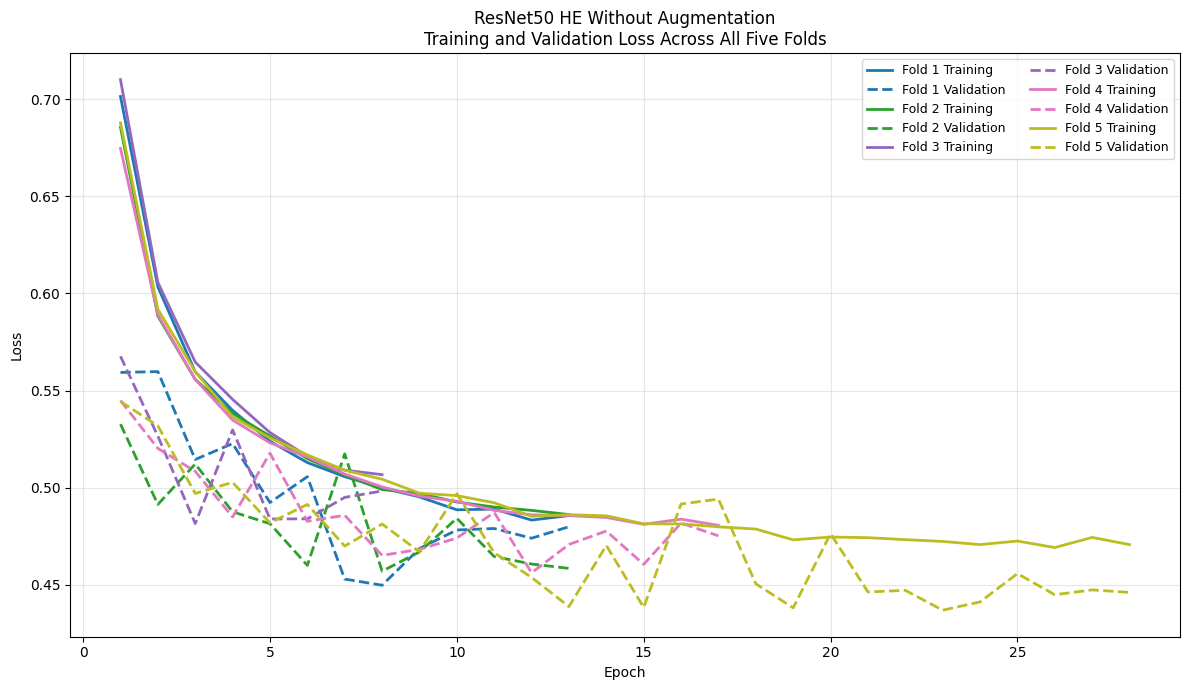

In [22]:
# Individual graph for each fold
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    sharey=True
)

axes = axes.flatten()

for index, (fold, fold_history) in enumerate(
    fold_histories.items()
):
    ax = axes[index]

    epochs = np.arange(1, len(fold_history) + 1)
    best_epoch_fold = fold_history["val_loss"].idxmin() + 1
    best_val_loss = fold_history["val_loss"].min()

    ax.plot(
        epochs,
        fold_history["loss"],
        color="steelblue",
        linewidth=2,
        label="Training Loss"
    )

    ax.plot(
        epochs,
        fold_history["val_loss"],
        color="darkorange",
        linewidth=2,
        label="Validation Loss"
    )

    ax.axvline(
        best_epoch_fold,
        color="red",
        linestyle="--",
        label=f"Best Epoch: {best_epoch_fold}"
    )

    ax.scatter(
        best_epoch_fold,
        best_val_loss,
        color="red",
        s=60,
        zorder=5
    )

    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.delaxes(axes[5])

plt.suptitle(
    "ResNet50 HE Without Augmentation\n"
    "Training and Validation Loss by Fold",
    fontsize=16
)

plt.tight_layout()
plt.show()


# All folds together
plt.figure(figsize=(12, 7))

colors = [
    "tab:blue",
    "tab:green",
    "tab:purple",
    "tab:pink",
    "tab:olive"
]

for (fold, fold_history), color in zip(
    fold_histories.items(),
    colors
):
    epochs = range(1, len(fold_history) + 1)

    plt.plot(
        epochs,
        fold_history["loss"],
        color=color,
        linewidth=2,
        label=f"Fold {fold} Training"
    )

    plt.plot(
        epochs,
        fold_history["val_loss"],
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"Fold {fold} Validation"
    )

plt.title(
    "ResNet50 HE Without Augmentation\n"
    "Training and Validation Loss Across All Five Folds"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

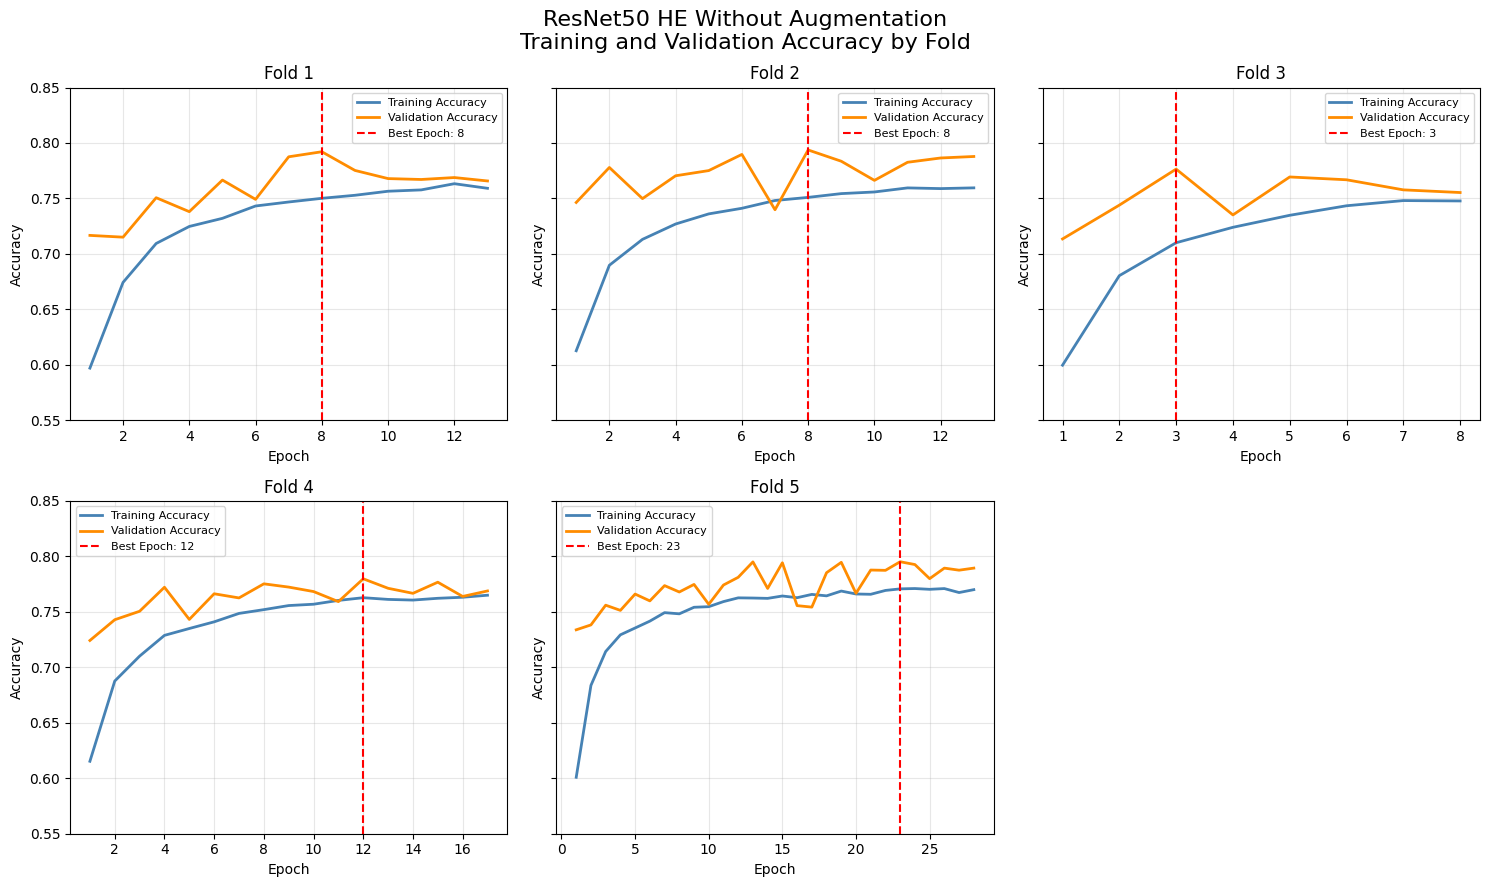

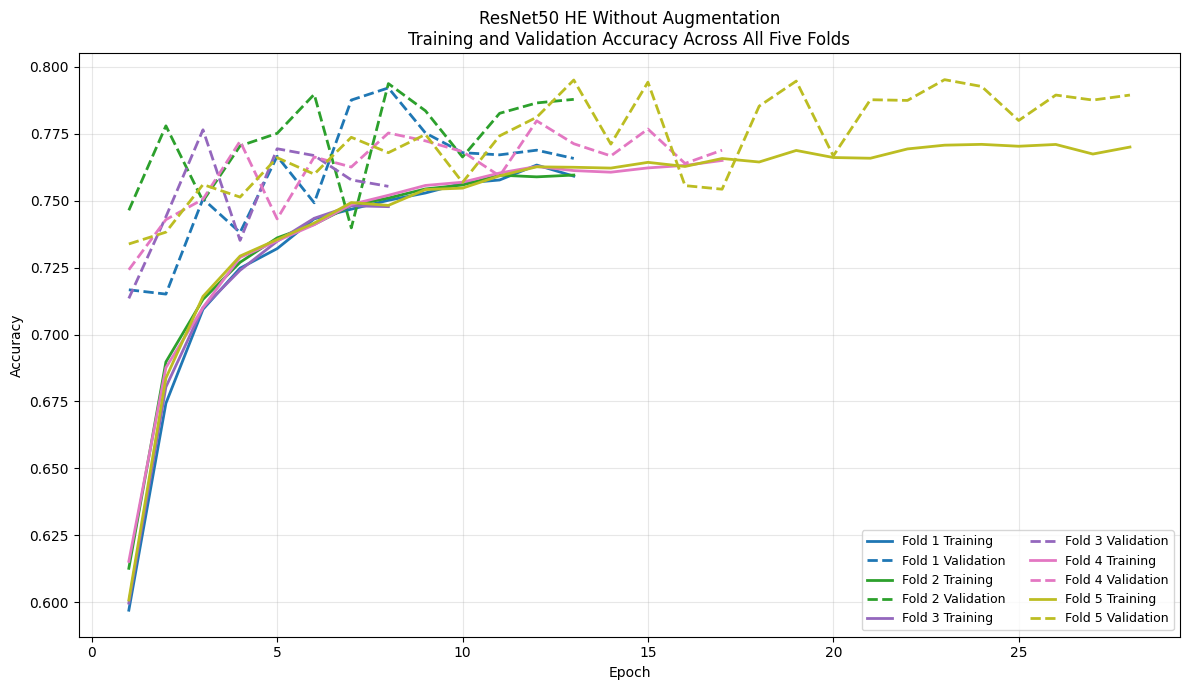

In [23]:
# Individual graph for each fold
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    sharey=True
)

axes = axes.flatten()

for index, (fold, fold_history) in enumerate(
    fold_histories.items()
):
    ax = axes[index]

    epochs = np.arange(1, len(fold_history) + 1)
    best_epoch_fold = fold_history["val_loss"].idxmin() + 1

    ax.plot(
        epochs,
        fold_history["accuracy"],
        color="steelblue",
        linewidth=2,
        label="Training Accuracy"
    )

    ax.plot(
        epochs,
        fold_history["val_accuracy"],
        color="darkorange",
        linewidth=2,
        label="Validation Accuracy"
    )

    ax.axvline(
        best_epoch_fold,
        color="red",
        linestyle="--",
        label=f"Best Epoch: {best_epoch_fold}"
    )

    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.55, 0.85)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.delaxes(axes[5])

plt.suptitle(
    "ResNet50 HE Without Augmentation\n"
    "Training and Validation Accuracy by Fold",
    fontsize=16
)

plt.tight_layout()
plt.show()


# All folds together
plt.figure(figsize=(12, 7))

colors = [
    "tab:blue",
    "tab:green",
    "tab:purple",
    "tab:pink",
    "tab:olive"
]

for (fold, fold_history), color in zip(
    fold_histories.items(),
    colors
):
    epochs = range(1, len(fold_history) + 1)

    plt.plot(
        epochs,
        fold_history["accuracy"],
        color=color,
        linewidth=2,
        label=f"Fold {fold} Training"
    )

    plt.plot(
        epochs,
        fold_history["val_accuracy"],
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"Fold {fold} Validation"
    )

plt.title(
    "ResNet50 HE Without Augmentation\n"
    "Training and Validation Accuracy Across All Five Folds"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

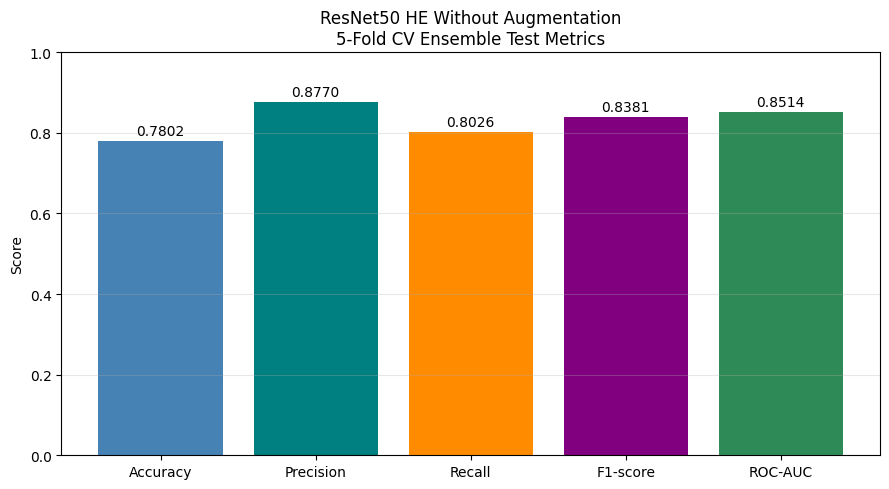

In [24]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

metric_values = [
    test_accuracy_cv,
    test_precision_cv,
    test_recall_cv,
    test_f1_cv,
    test_roc_auc_cv
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metric_names,
    metric_values,
    color=[
        "steelblue",
        "teal",
        "darkorange",
        "purple",
        "seagreen"
    ]
)

plt.ylim(0, 1)
plt.title(
    "ResNet50 HE Without Augmentation\n"
    "5-Fold CV Ensemble Test Metrics"
)
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

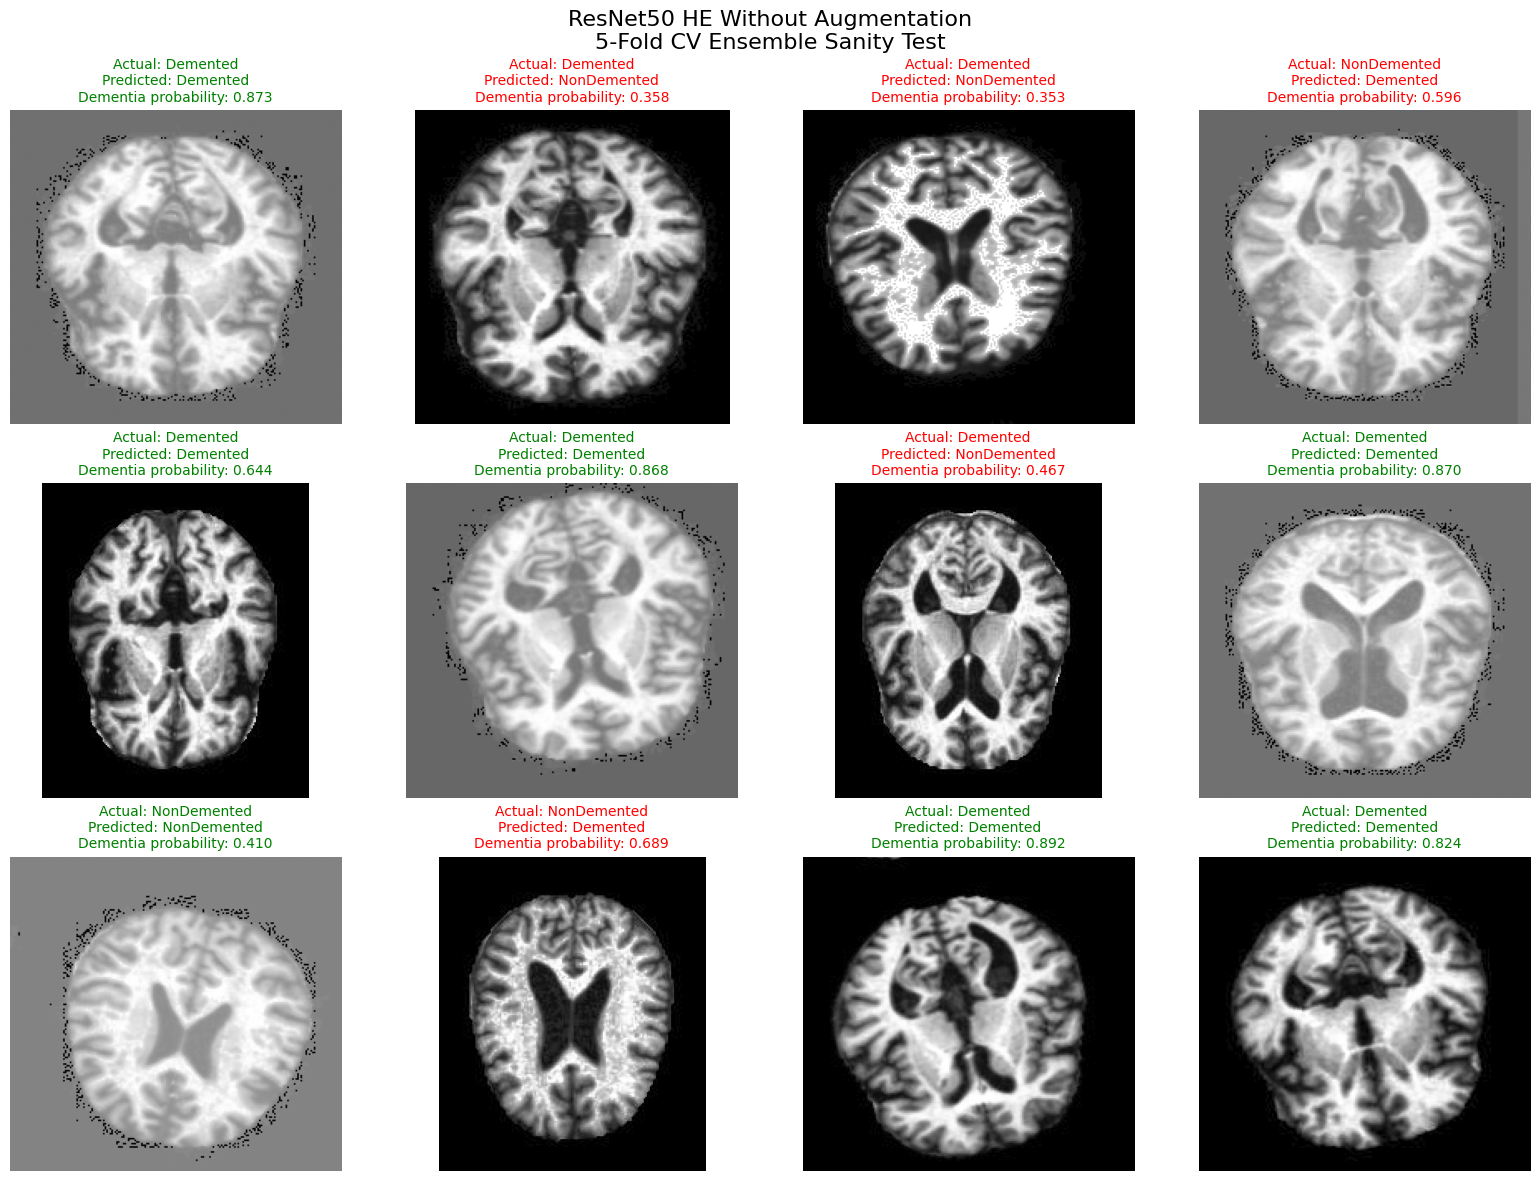

In [25]:
sample_indices = np.random.default_rng(SEED).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(sample_indices, start=1):
    original = cv2.imread(
        test_df.iloc[index]["filepath"],
        cv2.IMREAD_GRAYSCALE
    )

    processed = cv2.equalizeHist(original)

    actual = true_test_labels[index]
    predicted = test_predictions_cv[index]
    probability = test_probabilities_cv[index]

    actual_name = (
        "Demented" if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented" if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green" if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(processed, cmap="gray")
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Dementia probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle(
    "ResNet50 HE Without Augmentation\n"
    "5-Fold CV Ensemble Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [26]:
test_results_df = pd.DataFrame([{
    "Experiment": (
        "ResNet50 HE Without Augmentation "
        "+ 5-Fold CV"
    ),
    "Model": "ResNet50",
    "Preprocessing": "HE",
    "Augmentation": "No",
    "Cross-Validation": "5-Fold",
    "Test Loss": test_loss_cv,
    "Accuracy": test_accuracy_cv,
    "Precision": test_precision_cv,
    "Recall": test_recall_cv,
    "F1-score": test_f1_cv,
    "ROC-AUC": test_roc_auc_cv
}])

fold_results_df.to_csv(
    "/kaggle/working/"
    "resnet50_he_noaug_cv_fold_results.csv",
    index=False
)

cv_summary.to_csv(
    "/kaggle/working/"
    "resnet50_he_noaug_cv_summary.csv"
)

test_results_df.to_csv(
    "/kaggle/working/"
    "resnet50_he_noaug_cv_test_results.csv",
    index=False
)

for fold, fold_history in fold_histories.items():
    fold_history.to_csv(
        f"/kaggle/working/"
        f"resnet50_he_noaug_cv_fold_{fold}_history.csv",
        index=False
    )

display(test_results_df.round(4))

print("Saved:")
print("- Fold results CSV")
print("- Mean and standard-deviation summary CSV")
print("- Ensemble test-results CSV")
print("- Five training-history CSV files")
print("- Five best HE fold models")

,Experiment,Model,Preprocessing,Augmentation,Cross-Validation,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ResNet50 HE Without Augmentation + 5-Fold CV,ResNet50,HE,No,5-Fold,0.4624,0.7802,0.877,0.8026,0.8381,0.8514


Saved:
- Fold results CSV
- Mean and standard-deviation summary CSV
- Ensemble test-results CSV
- Five training-history CSV files
- Five best HE fold models
